# Credit Card Fraud Detection using SMOTE

This notebook implements a fraud detection system utilizing a European Credit Fraud dataset (`creditcard.csv`). The dataset contains highly imbalanced, PCA-transformed features.

**Objective:**
Compare Logistic Regression, Naive Bayes, and Random Forest classifiers. We will benchmark models trained on the raw imbalanced data against models trained on data augmented with Synthetic Minority Over-sampling Technique (SMOTE).

**Evaluation Metrics:**
Because of the heavy class imbalance, rely on the Area Under the Precision-Recall Curve (AUPRC), True Positive Rate (Recall/Sensitivity), ROC curves, and confusion matrices. Minimizing false negatives is the highest priority.

[Link to the Dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

---------------------
# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn prep and metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve,
                             auc, precision_recall_curve, average_precision_score)

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Imbalanced-learn for SMOTE
from imblearn.over_sampling import SMOTE

# Set plotting style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## Data Description
* **Source:** Kaggle, containing transactions made by European credit card holders over two days.
* **Size:** 284,807 total transactions.
* **`Class` Target:** 0 = Legitimate, 1 = Fraud.
* **Imbalance:** The dataset is highly imbalanced, with frauds accounting for only ~0.172% of all transactions.
* **Features:** `Amount` and `Time` features are not originally transformed, but we standardize them during preprocessing.
* **Anonymization:** All other features (V1-V28) are PCA transformed for user confidentiality.

-----------------
# Load and Scale Data

Ensure `creditcard.csv` is loaded in environment

Most data is already PCA scaled, so we'll just do Time and Amount columns

In [ ]:
# Load the dataset 'creditcard.csv'
df = pd.read_csv('creditcard.csv')

# Inspect fraud imbalance
print("\Fraud (Class) Distribution:")
print(df['Class'].value_counts(normalize=True) * 100)

# All other columns are already scaled
scaler = StandardScaler()
df['Scaled_Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df['Scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# Drop original Time and Amount columns
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Rearrange columns to put 'Class' at the end
scaled_amount = df['Scaled_Amount']
scaled_time = df['Scaled_Time']
df.drop(['Scaled_Amount', 'Scaled_Time'], axis=1, inplace=True)
df.insert(0, 'Scaled_Amount', scaled_amount)
df.insert(1, 'Scaled_Time', scaled_time)

df.head()

\Fraud (Class) Distribution:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


,Scaled_Amount,Scaled_Time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,0.244964,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.342475,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,1.160686,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,0.140534,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-0.073403,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


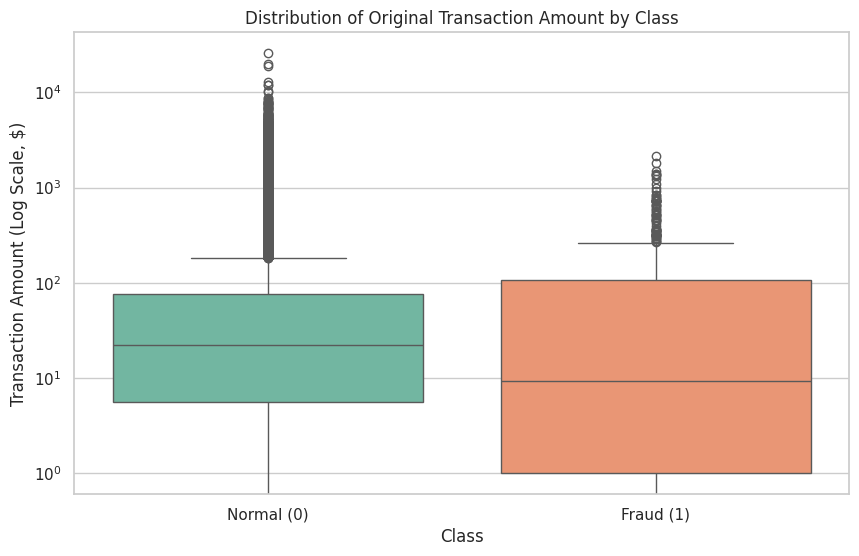

In [ ]:
## Transaction Amount (not transformed) to compare legitimate vs fraud

# Load the original dataset to access non-transformed 'Amount'
df_orig = pd.read_csv('creditcard.csv')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Class', y='Amount', data=df_orig, palette='Set2')
plt.title('Distribution of Original Transaction Amount by Class')
plt.yscale('log') # Log scale helps visualize the wide range of amounts
plt.xticks([0, 1], ['Normal (0)', 'Fraud (1)'])
plt.ylabel('Transaction Amount (Log Scale, $)')
plt.xlabel('Class')
plt.show()

--------------
## Train/Test split 80/20

In [ ]:
import numpy as np

# Separate features and target
# There's ONE instance where Class is null
# print(df.shape)
df.dropna(inplace=True)
# print(df.shape)
X = df.drop('Class', axis=1)
y = df['Class']

# 80/20 split
# Stratify ensures the same ratio of fraud/normal in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

----------------
# SMOTE Setup
SMOTE will oversample the minority class (Fraud) so that the model has more data to learn with

In [ ]:
print(f"Test set shape: {X_test.shape}")
print(f"Original Training set shape: {X_train.shape}")

# Apply SMOTE only to the training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nSMOTE Training set shape: {X_train_smote.shape}")
print("SMOTE Training Class Distribution:")
print(pd.Series(y_train_smote).value_counts())

Test set shape: (56962, 30)
Original Training set shape: (227845, 30)

SMOTE Training set shape: (454902, 30)
SMOTE Training Class Distribution:
Class
0    227451
1    227451
Name: count, dtype: int64


----------------
# Random Undersampling Setup
Experiment to undersample the majority class (not Fraud) to balance the dataset instead of oversampling the minority class (Fraud).

In [ ]:
# Imbalanced-learn for Undersampling
from imblearn.under_sampling import RandomUnderSampler

# Apply RandomUnderSampler to the training set
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(f"\nUndersampled Training set shape: {X_train_rus.shape}")
print("Undersampled Training Class Distribution:")
print(pd.Series(y_train_rus).value_counts())



Undersampled Training set shape: (788, 30)
Undersampled Training Class Distribution:
Class
0    394
1    394
Name: count, dtype: int64


--------------------
# Evaluation Helper Function
Will predict & plot our metrics

In [ ]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Predicts and plots Confusion Matrix, ROC Curve, and Precision-Recall Curve.
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Evaluation Metrics: {model_name}', fontsize=16)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
    axes[0].set_title('Confusion Matrix')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_title('Receiver Operating Characteristic')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc="lower right")

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    axes[2].plot(recall, precision, color='green', lw=2, label=f'PR curve (AUPRC = {pr_auc:.3f})')
    axes[2].set_title('Precision-Recall Curve')
    axes[2].set_xlabel('Recall (True Positive Rate)')
    axes[2].set_ylabel('Precision')
    axes[2].legend(loc="lower left")

    plt.tight_layout()
    plt.show()

    # Print Classification Report for Fraud (Class 1) Recall
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, y_pred))

-----------
# Evaluate Baseline Models
Without SMOTE, so we can see if things improve

Note - Class `0` represents not fraud, `1` represents fraud.

**Results:** High precision but low recall for Logistic Regression (64%) and Random Forest (76%). Naive Bayes has better recall (85%) but terrible precision (6%).

--- TRAINING BASELINE MODELS (CONTROL) ---


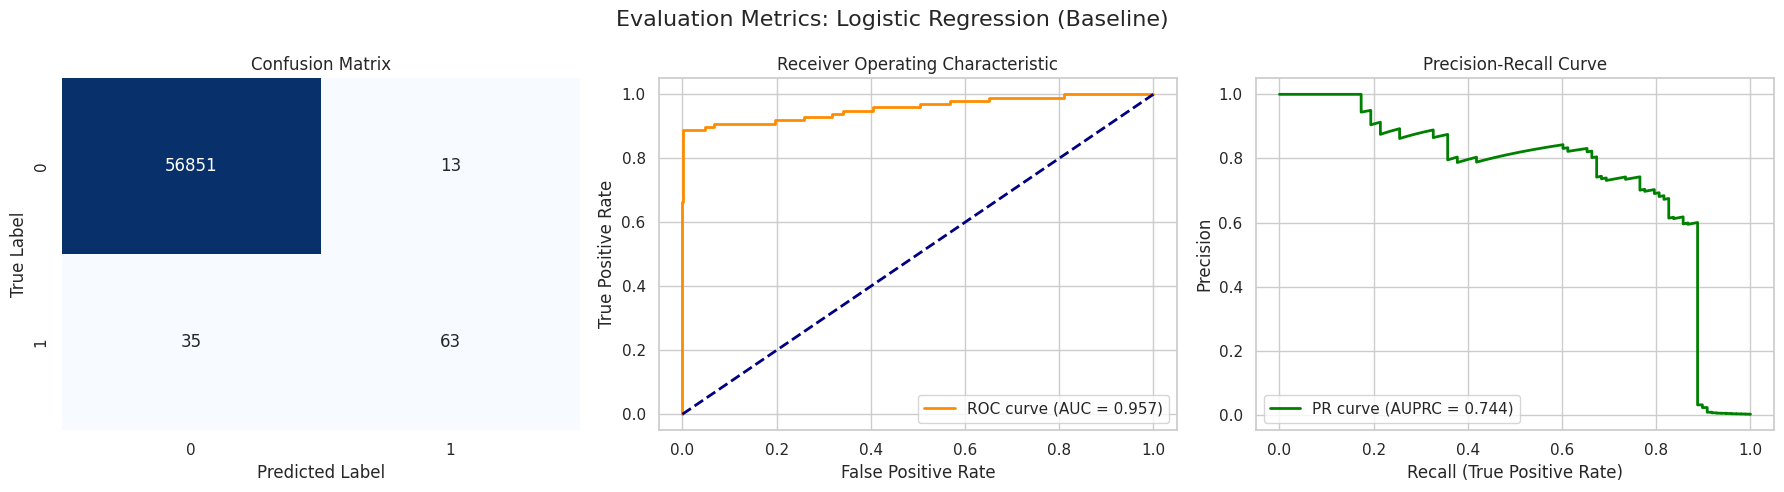

Classification Report for Logistic Regression (Baseline):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



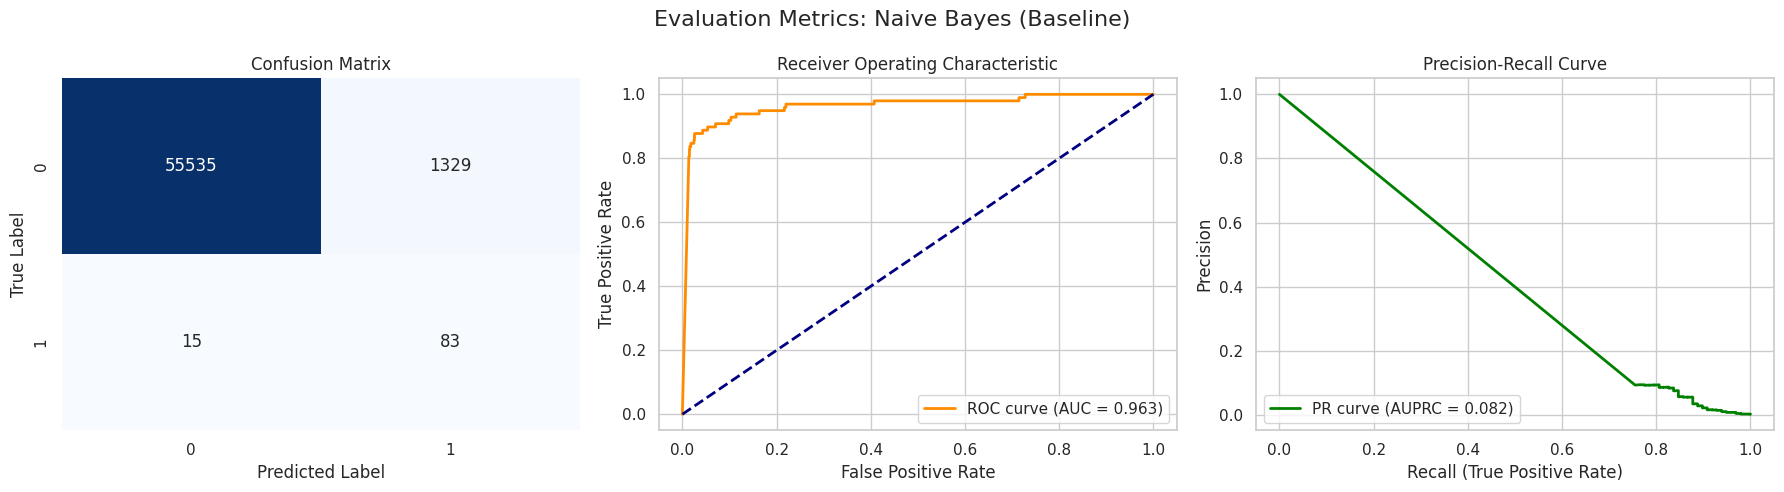

Classification Report for Naive Bayes (Baseline):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.85      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.91      0.55     56962
weighted avg       1.00      0.98      0.99     56962



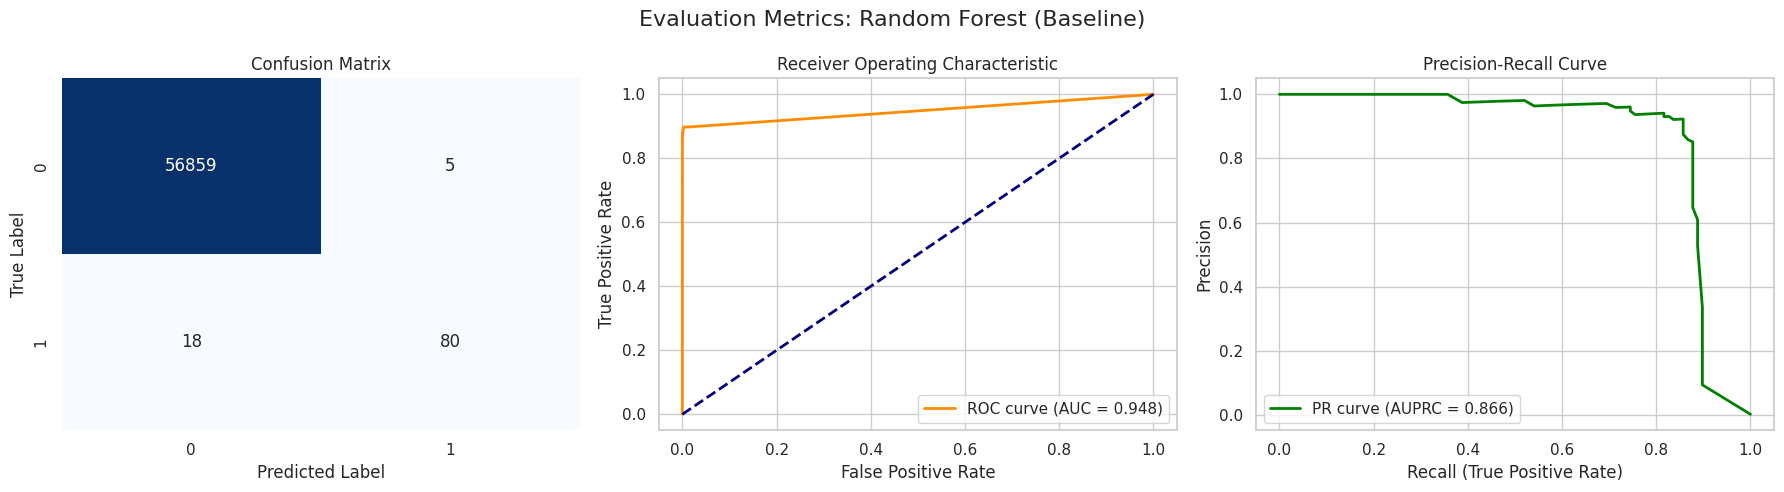

Classification Report for Random Forest (Baseline):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
# Initialize models
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
nb_baseline = GaussianNB()
rf_baseline = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

print("--- TRAINING BASELINE MODELS (CONTROL) ---")

# Logistic Regression Baseline
lr_baseline.fit(X_train, y_train)
evaluate_model(lr_baseline, X_test, y_test, "Logistic Regression (Baseline)")

# Naive Bayes Baseline
nb_baseline.fit(X_train, y_train)
evaluate_model(nb_baseline, X_test, y_test, "Naive Bayes (Baseline)")

# Random Forest Baseline
rf_baseline.fit(X_train, y_train)
evaluate_model(rf_baseline, X_test, y_test, "Random Forest (Baseline)")

----------
# Evaluate SMOTE Models
Hopefully better!

**Results:** Recall improved significantly for LR (92%) and NB (88%), but Precision tanked to ~5-6%. Random Forest maintained good Precision (88%) and improved Recall (83%).

--- TRAINING MODELS WITH SMOTE AUGMENTATION ---


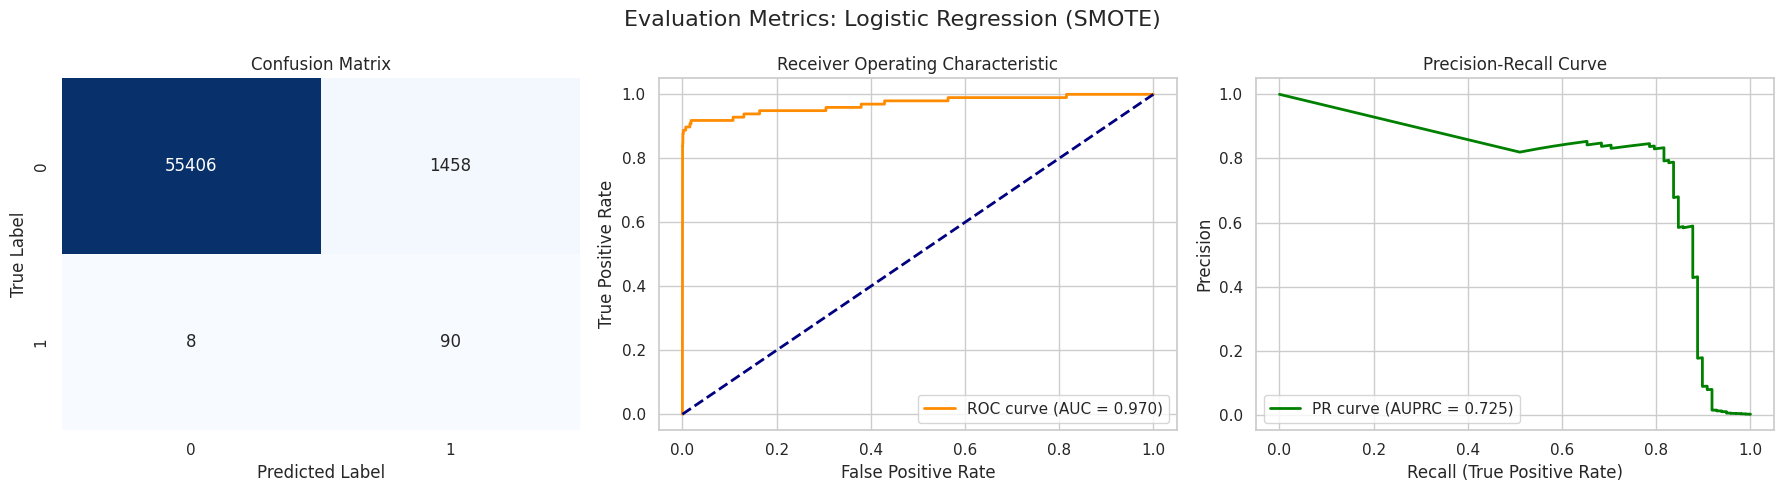

Classification Report for Logistic Regression (SMOTE):
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



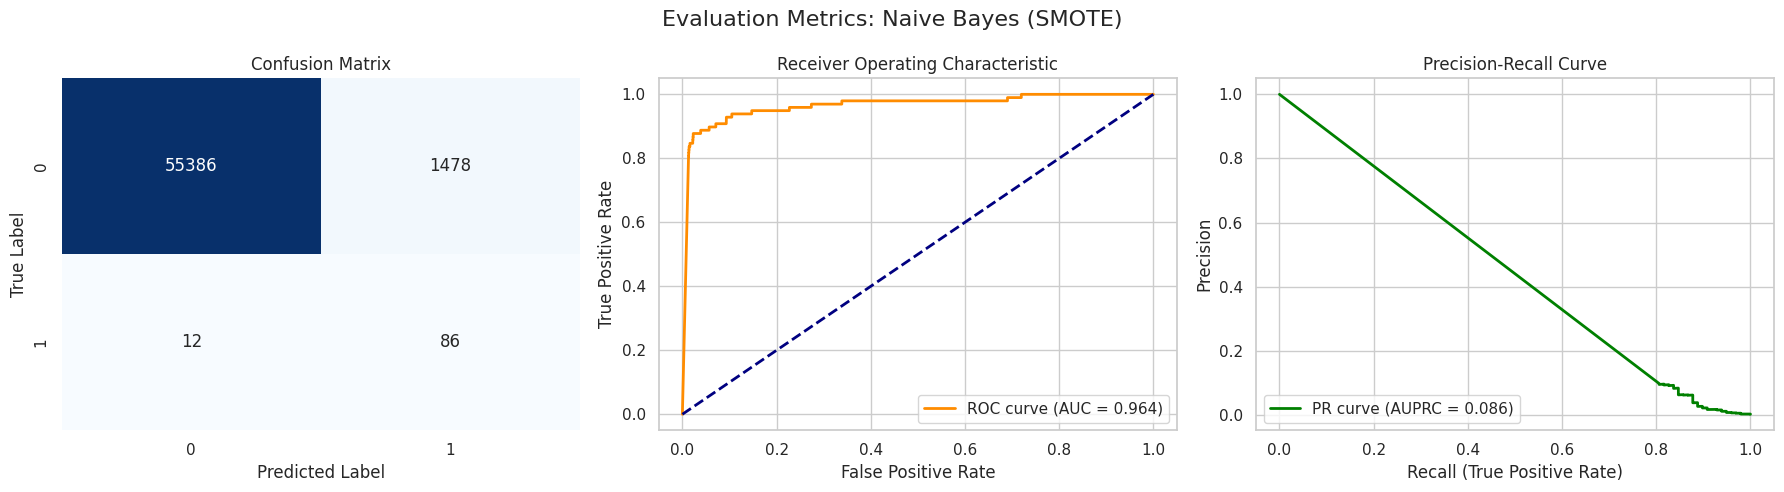

Classification Report for Naive Bayes (SMOTE):
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.05      0.88      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.93      0.55     56962
weighted avg       1.00      0.97      0.99     56962



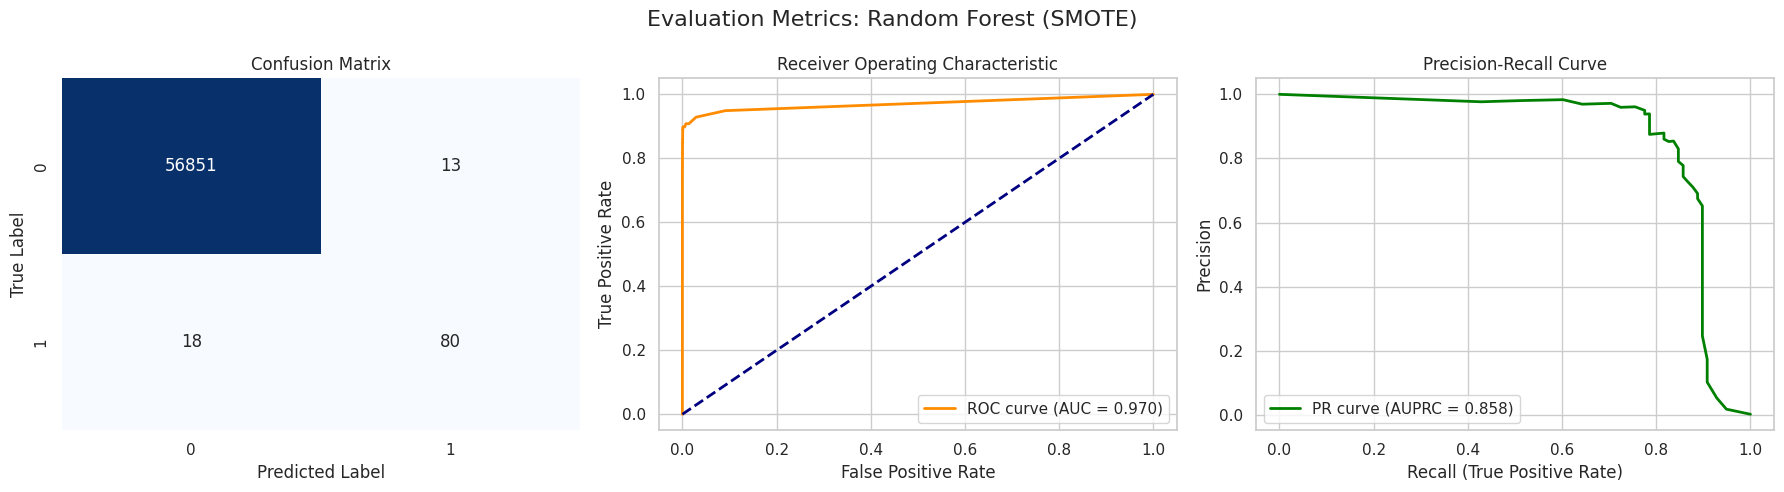

Classification Report for Random Forest (SMOTE):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.82      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
# Initialize models
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
nb_smote = GaussianNB()
rf_smote = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

print("--- TRAINING MODELS WITH SMOTE AUGMENTATION ---")

# Logistic Regression with SMOTE
lr_smote.fit(X_train_smote, y_train_smote)
evaluate_model(lr_smote, X_test, y_test, "Logistic Regression (SMOTE)")

# Naive Bayes with SMOTE
nb_smote.fit(X_train_smote, y_train_smote)
evaluate_model(nb_smote, X_test, y_test, "Naive Bayes (SMOTE)")

# Random Forest with SMOTE
rf_smote.fit(X_train_smote, y_train_smote)
evaluate_model(rf_smote, X_test, y_test, "Random Forest (SMOTE)")

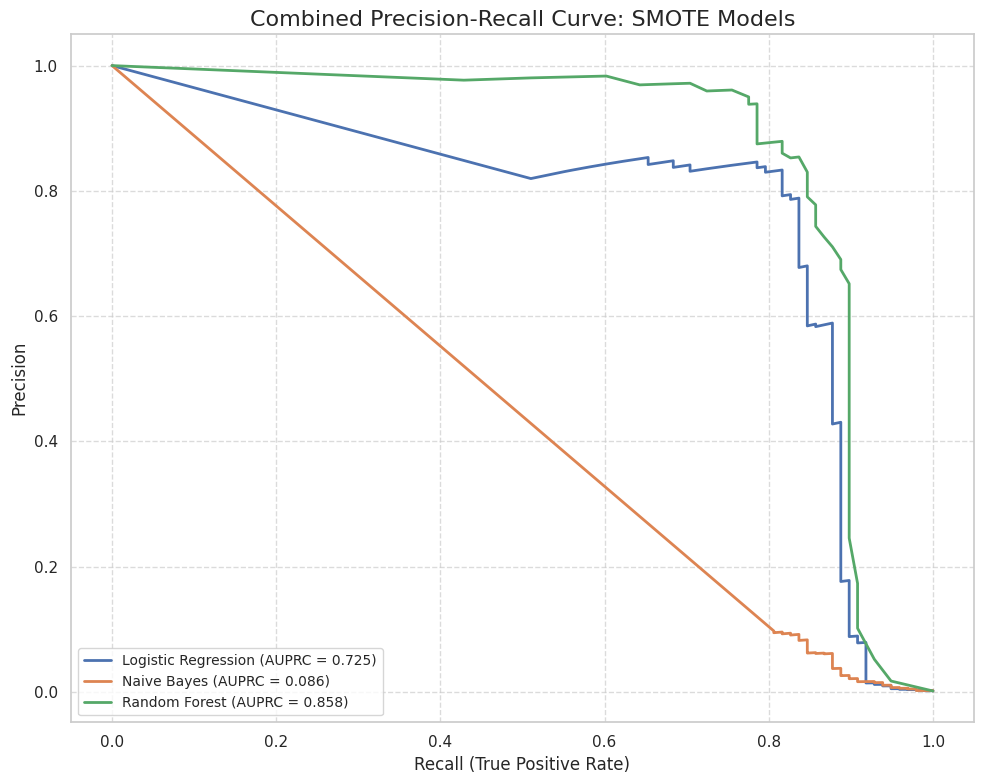

In [ ]:
# Combined SMOTE graphs for presentation
plt.figure(figsize=(10, 8))

# Logistic Regression (SMOTE)
lr_prob = lr_smote.predict_proba(X_test)[:, 1]
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_prob)
lr_auprc = average_precision_score(y_test, lr_prob)
plt.plot(lr_recall, lr_precision, lw=2, label=f'Logistic Regression (AUPRC = {lr_auprc:.3f})')

# Naive Bayes (SMOTE)
nb_prob = nb_smote.predict_proba(X_test)[:, 1]
nb_precision, nb_recall, _ = precision_recall_curve(y_test, nb_prob)
nb_auprc = average_precision_score(y_test, nb_prob)
plt.plot(nb_recall, nb_precision, lw=2, label=f'Naive Bayes (AUPRC = {nb_auprc:.3f})')

# Random Forest (SMOTE)
rf_prob = rf_smote.predict_proba(X_test)[:, 1]
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_prob)
rf_auprc = average_precision_score(y_test, rf_prob)
plt.plot(rf_recall, rf_precision, lw=2, label=f'Random Forest (AUPRC = {rf_auprc:.3f})')

plt.title('Combined Precision-Recall Curve: SMOTE Models', fontsize=16)
plt.xlabel('Recall (True Positive Rate)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(loc="lower left", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

-----------------------
# Evaluate Undersampling
This reduced our dataset to 394 entries of valid transactions and 394 instances of fraud. It will be interesting to see whether this technique can produce good results when it reduces our quantity of test data so drastically. Perhaps this will be a matter of quantity vs. quality.

**Results:** High recall (~92%), but Precision dropped drastically across all models (to ~4%).

--- TRAINING MODELS WITH UNDERSAMPLING ---


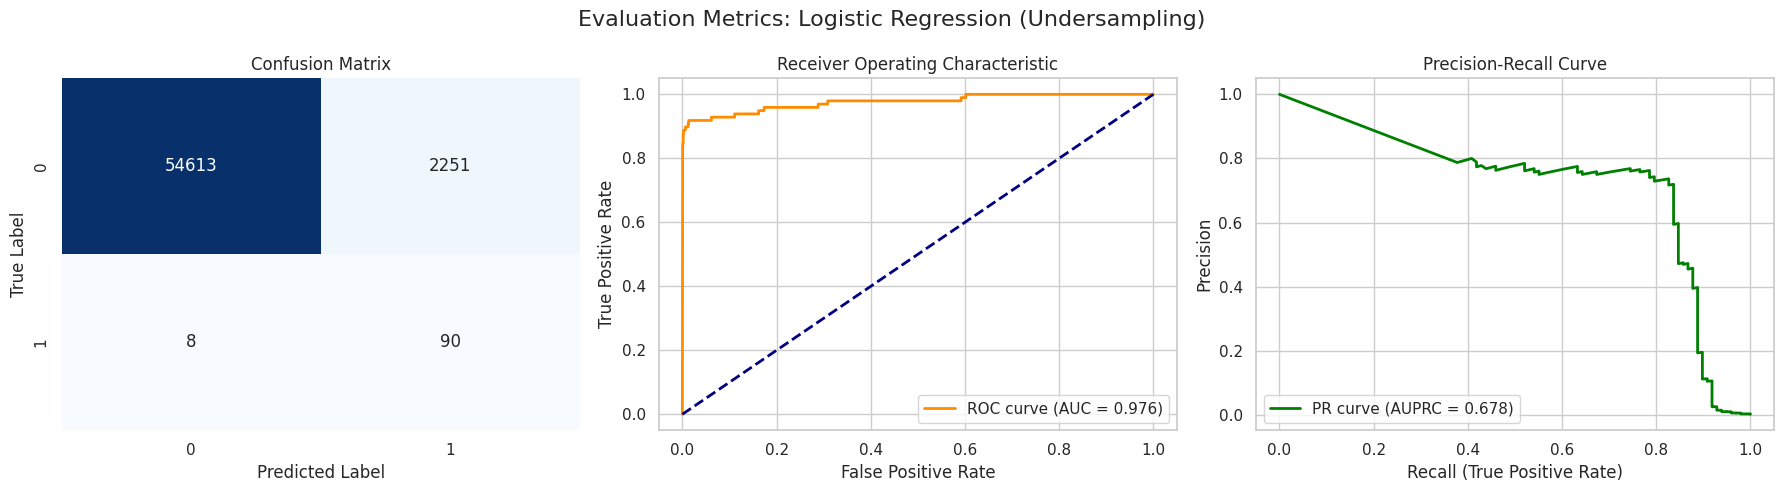

Classification Report for Logistic Regression (Undersampling):
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962



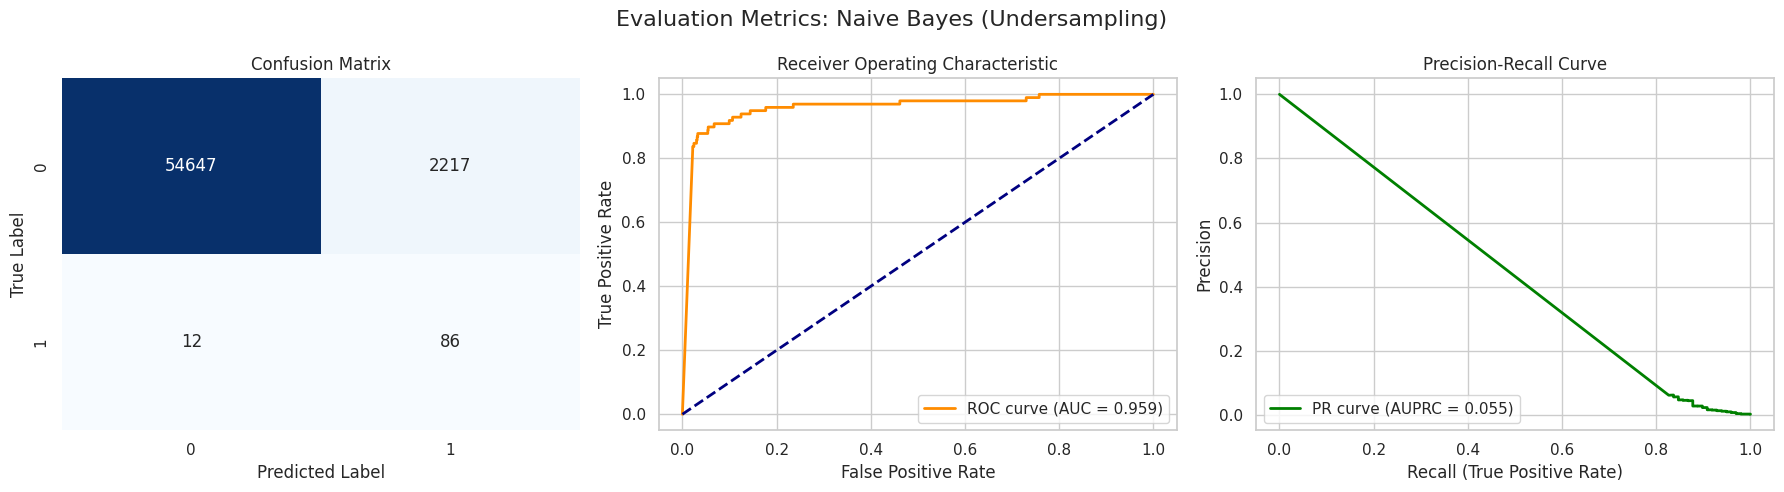

Classification Report for Naive Bayes (Undersampling):
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.88      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.92      0.53     56962
weighted avg       1.00      0.96      0.98     56962



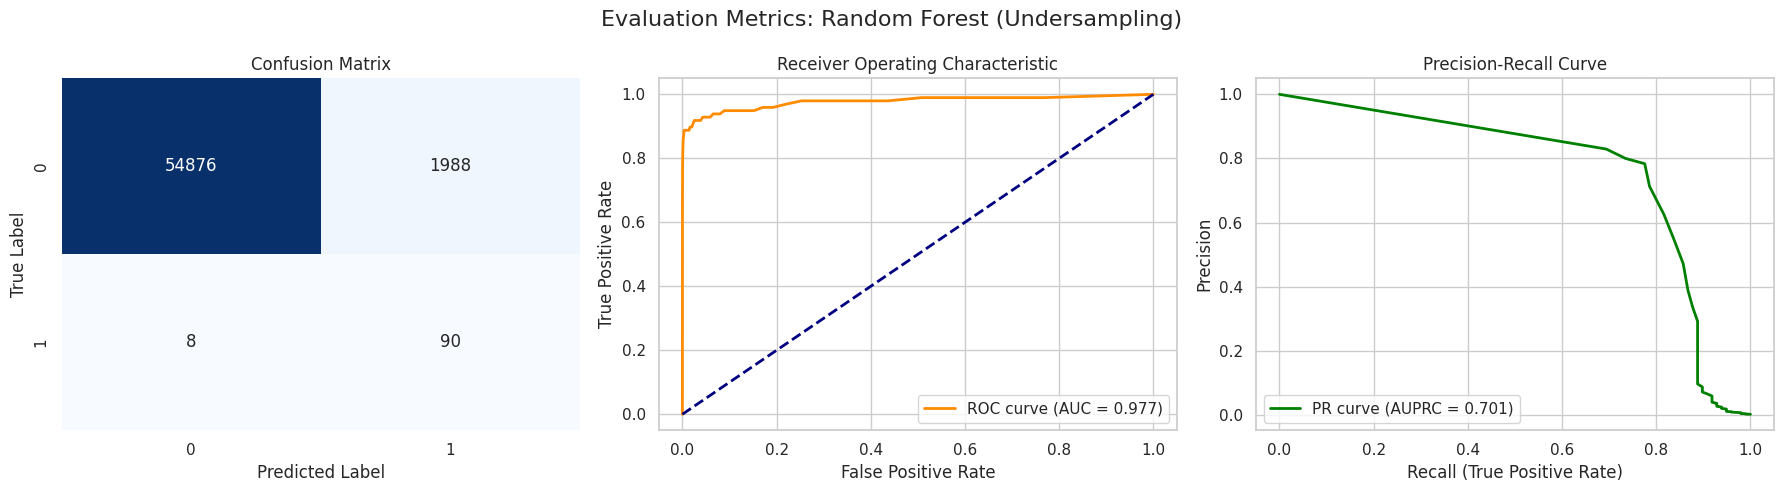

Classification Report for Random Forest (Undersampling):
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.04      0.92      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962



In [ ]:
# Initialize models for undersampled data
lr_rus = LogisticRegression(max_iter=1000, random_state=42)
nb_rus = GaussianNB()
rf_rus = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

print("--- TRAINING MODELS WITH UNDERSAMPLING ---")

# Logistic Regression with Undersampling
lr_rus.fit(X_train_rus, y_train_rus)
evaluate_model(lr_rus, X_test, y_test, "Logistic Regression (Undersampling)")

# Naive Bayes with Undersampling
nb_rus.fit(X_train_rus, y_train_rus)
evaluate_model(nb_rus, X_test, y_test, "Naive Bayes (Undersampling)")

# Random Forest with Undersampling
rf_rus.fit(X_train_rus, y_train_rus)
evaluate_model(rf_rus, X_test, y_test, "Random Forest (Undersampling)")


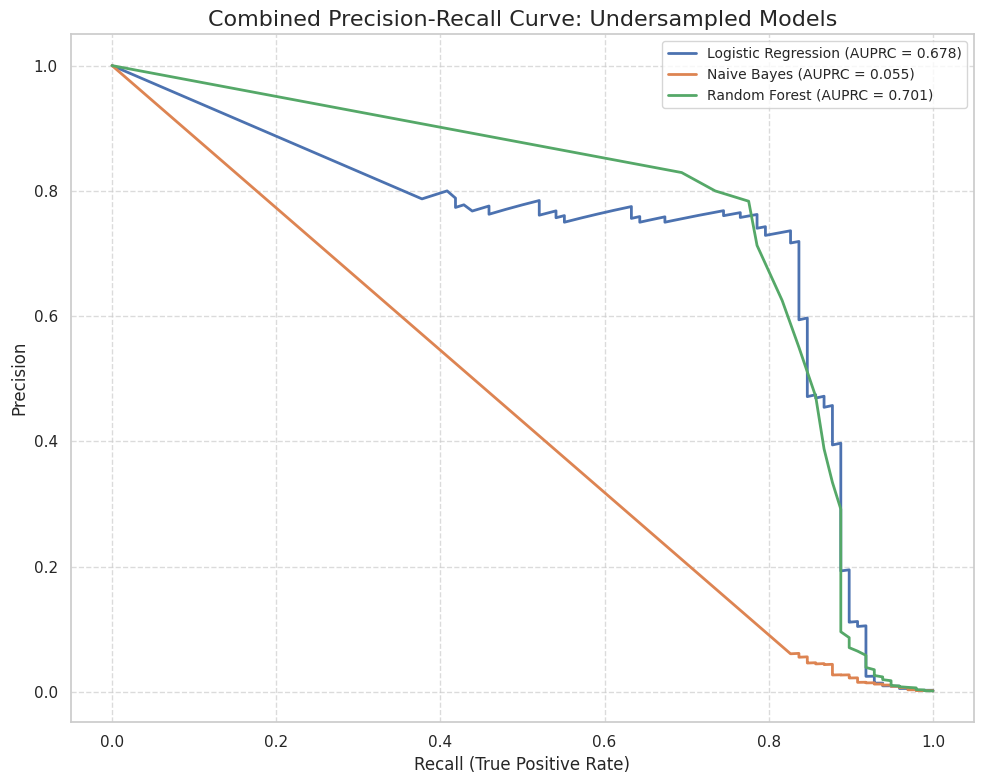

In [ ]:
# Combined Undersampling graphs for presentation
plt.figure(figsize=(10, 8))

# Logistic Regression (Undersampling)
lr_prob_rus = lr_rus.predict_proba(X_test)[:, 1]
lr_precision_rus, lr_recall_rus, _ = precision_recall_curve(y_test, lr_prob_rus)
lr_auprc_rus = average_precision_score(y_test, lr_prob_rus)
plt.plot(lr_recall_rus, lr_precision_rus, lw=2, label=f'Logistic Regression (AUPRC = {lr_auprc_rus:.3f})')

# Naive Bayes (Undersampling)
nb_prob_rus = nb_rus.predict_proba(X_test)[:, 1]
nb_precision_rus, nb_recall_rus, _ = precision_recall_curve(y_test, nb_prob_rus)
nb_auprc_rus = average_precision_score(y_test, nb_prob_rus)
plt.plot(nb_recall_rus, nb_precision_rus, lw=2, label=f'Naive Bayes (AUPRC = {nb_auprc_rus:.3f})')

# Random Forest (Undersampling)
rf_prob_rus = rf_rus.predict_proba(X_test)[:, 1]
rf_precision_rus, rf_recall_rus, _ = precision_recall_curve(y_test, rf_prob_rus)
rf_auprc_rus = average_precision_score(y_test, rf_prob_rus)
plt.plot(rf_recall_rus, rf_precision_rus, lw=2, label=f'Random Forest (AUPRC = {rf_auprc_rus:.3f})')

plt.title('Combined Precision-Recall Curve: Undersampled Models', fontsize=16)
plt.xlabel('Recall (True Positive Rate)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

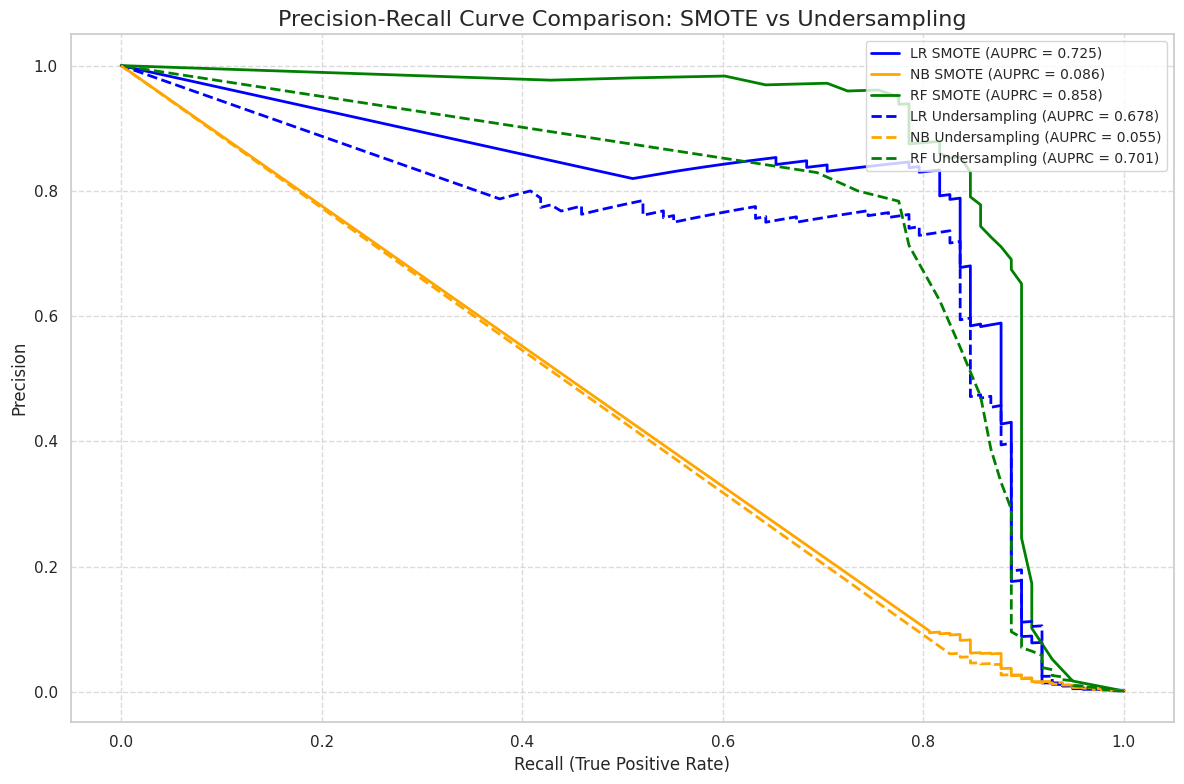

In [ ]:
# Comparison: SMOTE vs Undersampling
plt.figure(figsize=(12, 8))

# SMOTE (Solid lines, reusing variables from the SMOTE combined graph cell)
plt.plot(lr_recall, lr_precision, lw=2, linestyle='-', color='blue', label=f'LR SMOTE (AUPRC = {lr_auprc:.3f})')
plt.plot(nb_recall, nb_precision, lw=2, linestyle='-', color='orange', label=f'NB SMOTE (AUPRC = {nb_auprc:.3f})')
plt.plot(rf_recall, rf_precision, lw=2, linestyle='-', color='green', label=f'RF SMOTE (AUPRC = {rf_auprc:.3f})')

# Undersampling (Dashed lines, matching colors by model type)
plt.plot(lr_recall_rus, lr_precision_rus, lw=2, linestyle='--', color='blue', label=f'LR Undersampling (AUPRC = {lr_auprc_rus:.3f})')
plt.plot(nb_recall_rus, nb_precision_rus, lw=2, linestyle='--', color='orange', label=f'NB Undersampling (AUPRC = {nb_auprc_rus:.3f})')
plt.plot(rf_recall_rus, rf_precision_rus, lw=2, linestyle='--', color='green', label=f'RF Undersampling (AUPRC = {rf_auprc_rus:.3f})')

plt.title('Precision-Recall Curve Comparison: SMOTE vs Undersampling', fontsize=16)
plt.xlabel('Recall (True Positive Rate)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

-----------------------
# Theory testing
Here we test different strategies to improve precision (reduce false positives) while keeping recall high (catching most fraud).

-------------------
Threshold tuning result: really bad precision

In [ ]:
##
# Threshold Tuning (Using our previously trained SMOTE Logistic Regression)
##
print("--- THRESHOLD TUNING (LR SMOTE) ---")

# Get probabilities instead of pure class predictions
y_prob_smote = lr_smote.predict_proba(X_test)[:, 1]

# Shift the threshold up from 0.5 to 0.9
# We demand 90% confidence from the model before calling it fraud
custom_threshold = 0.9
y_pred_custom = (y_prob_smote >= custom_threshold).astype(int)

print(f"Classification Report for LR SMOTE with Custom Threshold ({custom_threshold}):")
print(classification_report(y_test, y_pred_custom))

--- THRESHOLD TUNING (LR SMOTE) ---
Classification Report for LR SMOTE with Custom Threshold (0.9):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.20      0.89      0.32        98

    accuracy                           0.99     56962
   macro avg       0.60      0.94      0.66     56962
weighted avg       1.00      0.99      1.00     56962



------------
Initial XGBoost result: bad recall

--- GRADIENT BOOSTING (XGBOOST) ---


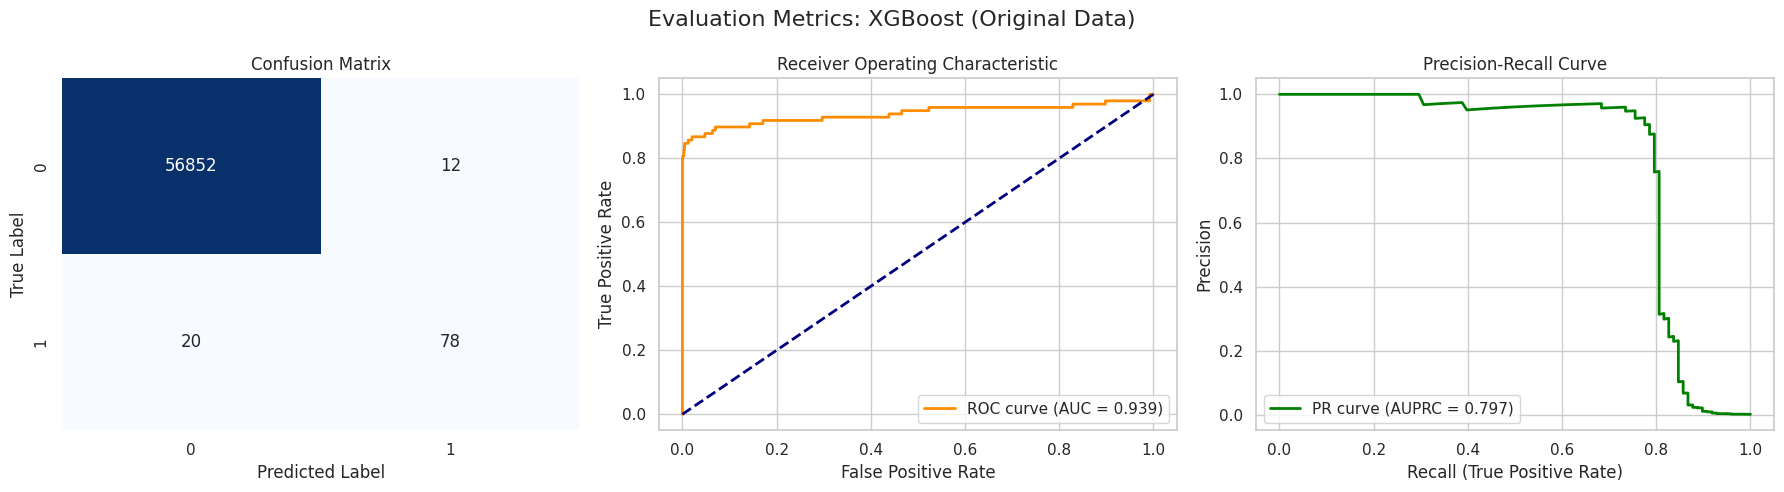

Classification Report for XGBoost (Original Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
# Gradient Boosting (XGBoost)
from xgboost import XGBClassifier

print("--- GRADIENT BOOSTING (XGBOOST) ---")
# Tree-based ensemble models often handle imbalanced data much better inherently
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# We train it on the original imbalanced data to test its native capability
xgb_model.fit(X_train, y_train)

evaluate_model(xgb_model, X_test, y_test, "XGBoost (Original Data)")

------------------
Cost-sensitive learning result: horrid precision

--- COST-SENSITIVE LEARNING ---


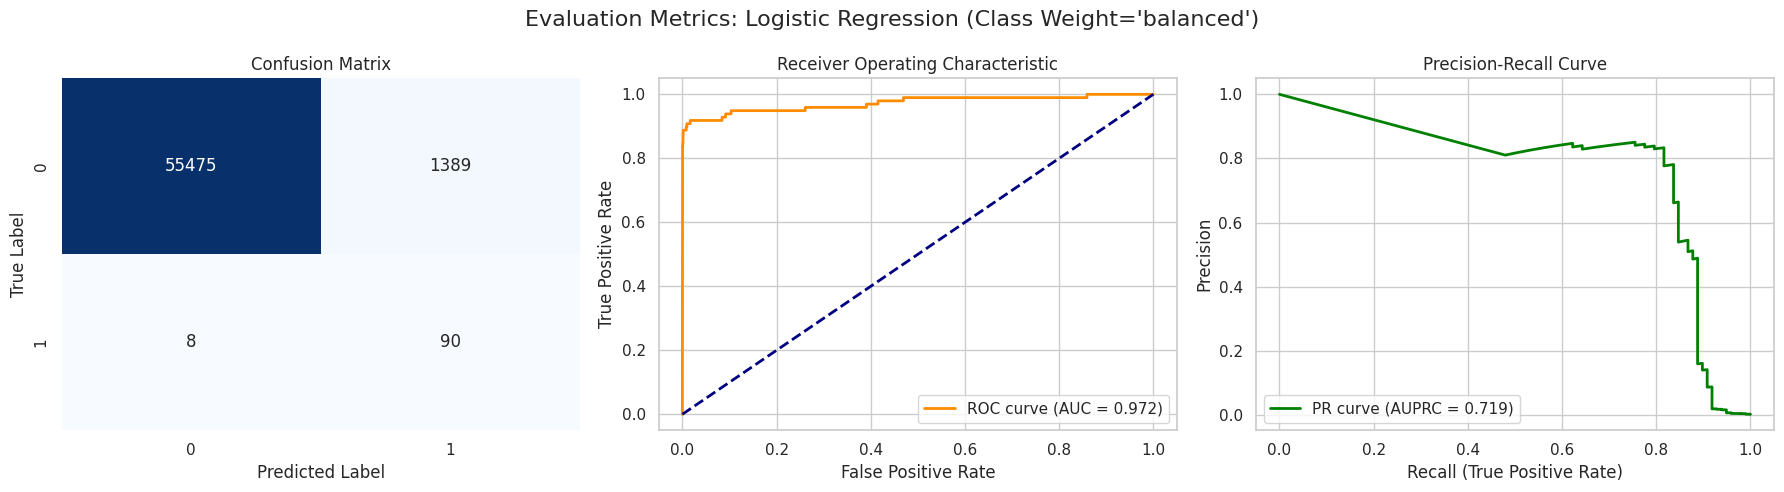

Classification Report for Logistic Regression (Class Weight='balanced'):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [ ]:
# Cost-Sensitive Learning
print("--- COST-SENSITIVE LEARNING ---")

# By setting class_weight='balanced', the algorithm automatically penalizes
# mistakes on the minority class (fraud) much more heavily.
lr_balanced = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_balanced.fit(X_train, y_train) # Note: original, un-augmented data

evaluate_model(lr_balanced, X_test, y_test, "Logistic Regression (Class Weight='balanced')")

---------------
SMOTE + ENN result: no better than original SMOTE and takes forever to run

In [ ]:
# This one's not any better and takes a long time to run
#Hybrid Sampling (SMOTE + ENN)
from imblearn.combine import SMOTEENN

# print("--- HYBRID SAMPLING (SMOTEENN) ---")
## This creates synthetic points (SMOTE) and then cleans up noisy borders (ENN)
# smote_enn = SMOTEENN(random_state=42)

## This takes awhile to run
# X_train_smenn, y_train_smenn = smote_enn.fit_resample(X_train, y_train)

# lr_smenn = LogisticRegression(max_iter=1000, random_state=42)
# lr_smenn.fit(X_train_smenn, y_train_smenn)

# evaluate_model(lr_smenn, X_test, y_test, "Logistic Regression (SMOTEENN)")

-----------------------
# XGBoost with Class Weighting (`scale_pos_weight`)
Let's calculate the ratio of negative to positive samples and pass it to XGBoost so it inherently pays more attention to the minority class.

**Results:** Very strong! 85% Recall and 89% Precision.

Calculated scale_pos_weight: 577.29

--- XGBOOST WITH SCALE_POS_WEIGHT ---


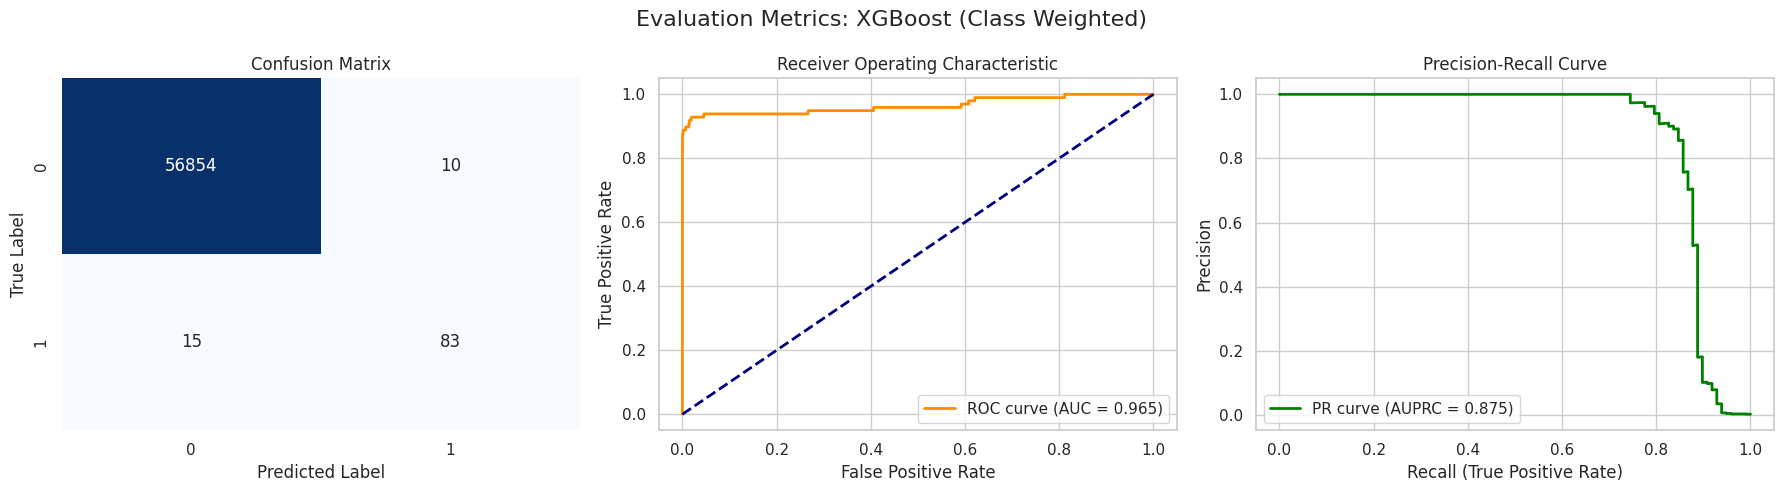

Classification Report for XGBoost (Class Weighted):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.85      0.87        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
# Calculate scale_pos_weight
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

print("\n--- XGBOOST WITH SCALE_POS_WEIGHT ---")
xgb_weighted = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_weighted.fit(X_train, y_train)

evaluate_model(xgb_weighted, X_test, y_test, "XGBoost (Class Weighted)")

-----------------------
# XGBoost with SMOTE
Now let's see how XGBoost performs when trained on the synthetically balanced data.

**Results:** Good, but slightly worse than Class Weighting (86% Recall, 72% Precision).

--- XGBOOST WITH SMOTE ---


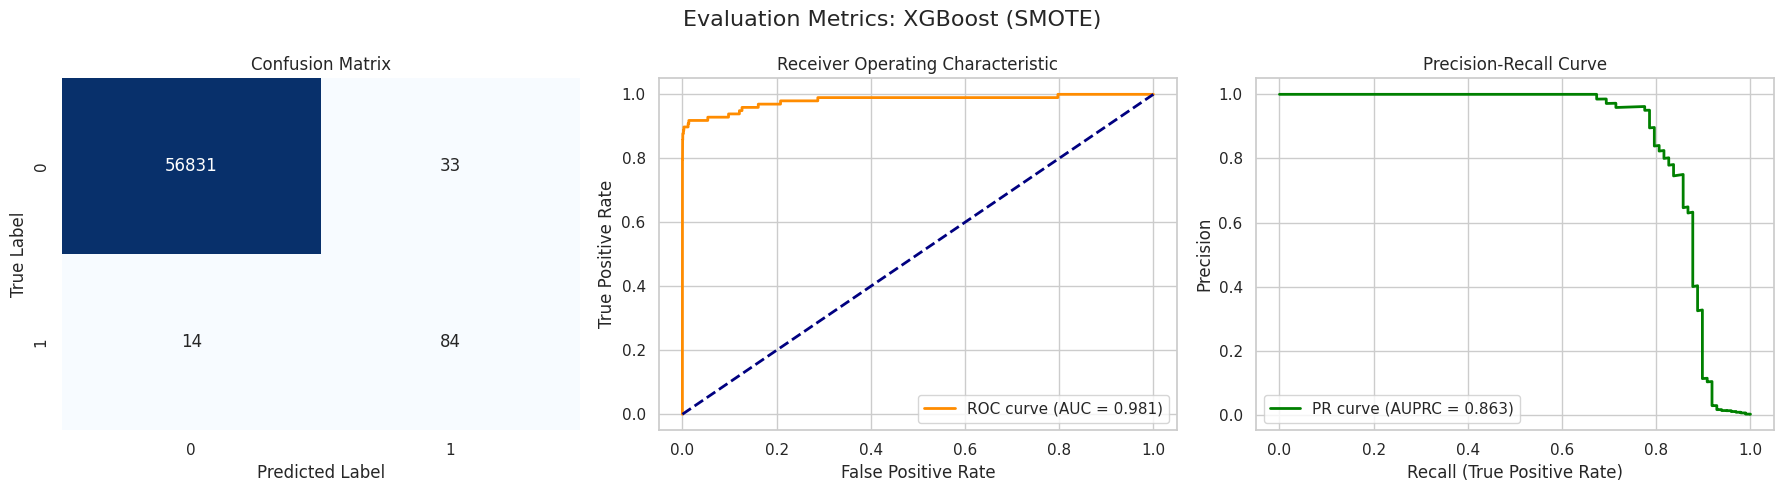

Classification Report for XGBoost (SMOTE):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.86      0.78        98

    accuracy                           1.00     56962
   macro avg       0.86      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
print("--- XGBOOST WITH SMOTE ---")
xgb_smote = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_smote.fit(X_train_smote, y_train_smote)

evaluate_model(xgb_smote, X_test, y_test, "XGBoost (SMOTE)")

-----------------------
# XGBoost Hyperparameter Tuning
We will use `RandomizedSearchCV` to find the best hyperparameters. We use randomized search to keep runtime manageable.
We're also back to using the original dataset, not the transformed SMOTE data.

**Results:** Excellent balance. 85% Recall and 86% Precision.

--- XGBOOST HYPERPARAMETER TUNING ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Hyperparameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.2}


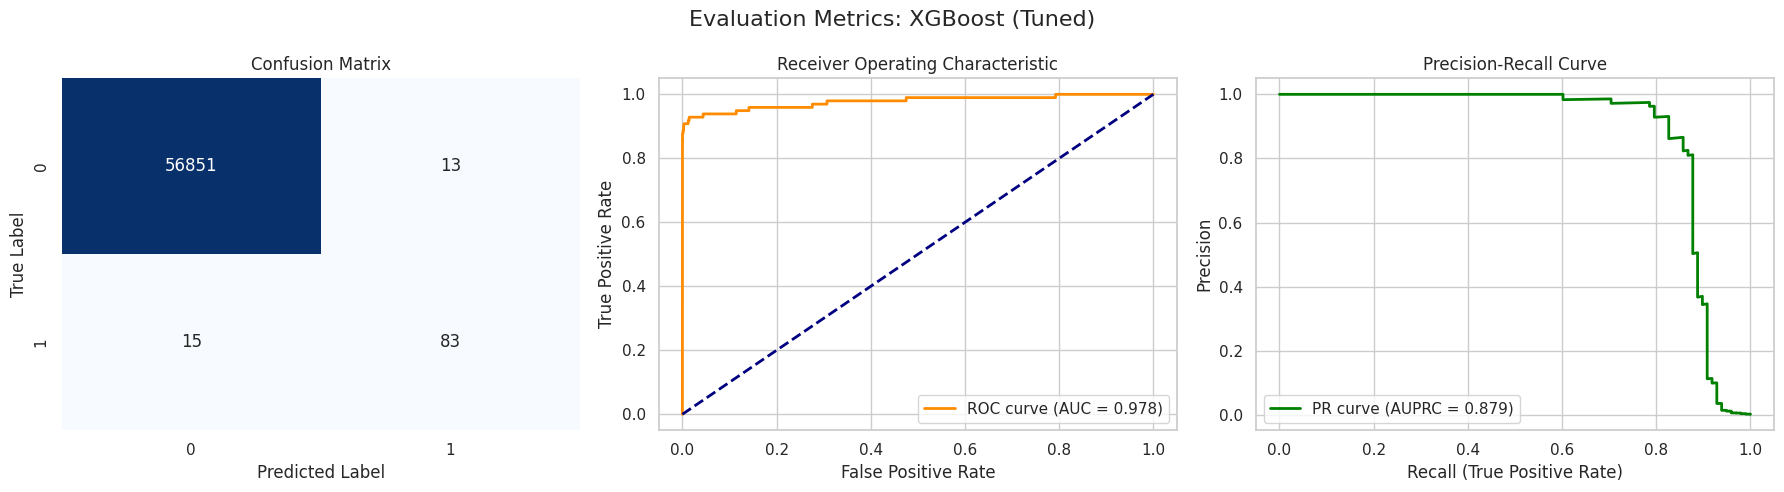

Classification Report for XGBoost (Tuned):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

print("--- XGBOOST HYPERPARAMETER TUNING ---")

# Define the parameter grid
param_dist = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'subsample': [0.8, 1.0]
}

# Initialize a base model
xgb_base = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, use_label_encoder=False, eval_metric='logloss')

# Setup RandomizedSearchCV (using AUPRC/average_precision for scoring due to imbalance)
random_search = RandomizedSearchCV(xgb_base, param_distributions=param_dist, n_iter=5, scoring='average_precision', cv=3, random_state=42, n_jobs=-1, verbose=1)

# Fit the random search model
random_search.fit(X_train, y_train)

print(f"Best Hyperparameters: {random_search.best_params_}")
best_xgb = random_search.best_estimator_

evaluate_model(best_xgb, X_test, y_test, "XGBoost (Tuned)")

-----------------------
# XGBoost Threshold Tuning

------- **BEST MODEL** -------

We extract the prediction probabilities from our tuned XGBoost model and evaluate different thresholds to see if we can optimize the Recall vs Precision tradeoff. Lowering the threshold will increase Recall (catch more fraud) but decrease Precision (more false alarms).

I cleaned this up a bit, originally I tested thresholds of 0.35, 0.4, 0.45, 0.5, 0.55 and 0.6. Since 0.4 was the best I kept that and removed the others so that this executes quicker.

**Results:** Our best model! Lowering the threshold to 0.4 yielded 86% Recall and 86% Precision.

--- THRESHOLD TUNING (TUNED XGBOOST) ---


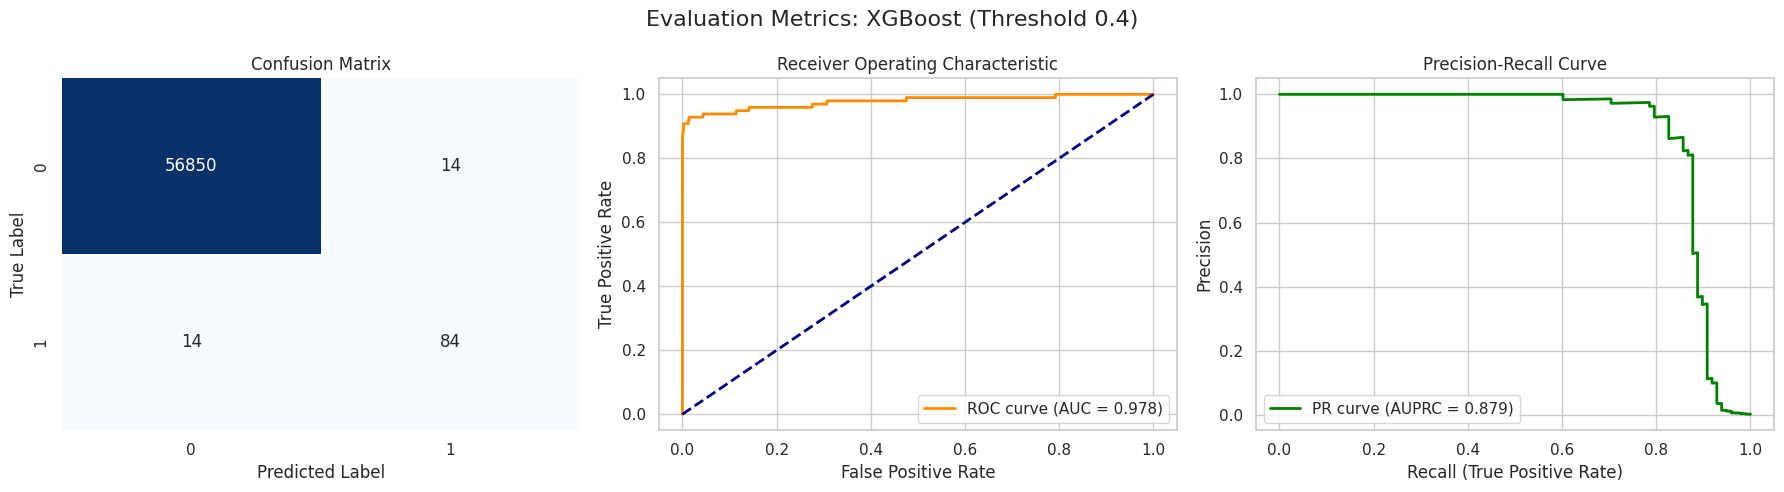

Classification Report for XGBoost (Threshold 0.4):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.86      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
print("--- THRESHOLD TUNING (TUNED XGBOOST) ---")

# Get probabilities for the positive class (fraud)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Let's test a slightly lower threshold to catch more fraud (favoring recall)
xgb_threshold = 0.4
y_pred_xgb_custom = (y_prob_xgb >= xgb_threshold).astype(int)

# To use our evaluate_model function with a custom threshold, we create a simple wrapper
class CustomThresholdModel:
    def __init__(self, model, threshold):
        self.model = model
        self.threshold = threshold
        if hasattr(model, 'classes_'):
            self.classes_ = model.classes_

    def predict(self, X):
        return (self.model.predict_proba(X)[:, 1] >= self.threshold).astype(int)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

# Evaluate the threshold-tuned model
threshold_xgb = CustomThresholdModel(best_xgb, xgb_threshold)
evaluate_model(threshold_xgb, X_test, y_test, f"XGBoost (Threshold {xgb_threshold})")

-----------------------
# Advanced XGBoost Hyperparameter Tuning
**THIS DIDN'T IMPROVE THINGS**

Here is a more exhaustive search space with more iterations.

*Note: Running 20 iterations with 3-fold cross-validation means 60 total model fits. I commented it out for now since it didn't improve and takes a long time to run.*

**Results:** Slightly overfit/missed the mark. 85% Recall, 84% Precision.

In [ ]:
# This didn't improve the model
print("--- ADVANCED XGBOOST HYPERPARAMETER TUNING ---")

# Expanded parameter grid
advanced_param_dist = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0], # Fraction of features to use per tree
    'min_child_weight': [1, 3, 5],       # Helps control over-fitting
    'gamma': [0, 0.1, 0.2]               # Minimum loss reduction required to make a further partition
}

# Setup RandomizedSearchCV with 20 iterations
advanced_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=advanced_param_dist,
    n_iter=20,
    scoring='average_precision',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Uncomment the lines below to run the advanced tuning!

# advanced_search.fit(X_train, y_train)
# print(f"Best Advanced Hyperparameters: {advanced_search.best_params_}")
# best_advanced_xgb = advanced_search.best_estimator_
# evaluate_model(best_advanced_xgb, X_test, y_test, "XGBoost (Advanced Tuned)")

--- ADVANCED XGBOOST HYPERPARAMETER TUNING ---


------------
## Feature Importance


--- FEATURE IMPORTANCES (BEST XGBOOST MODEL) ---


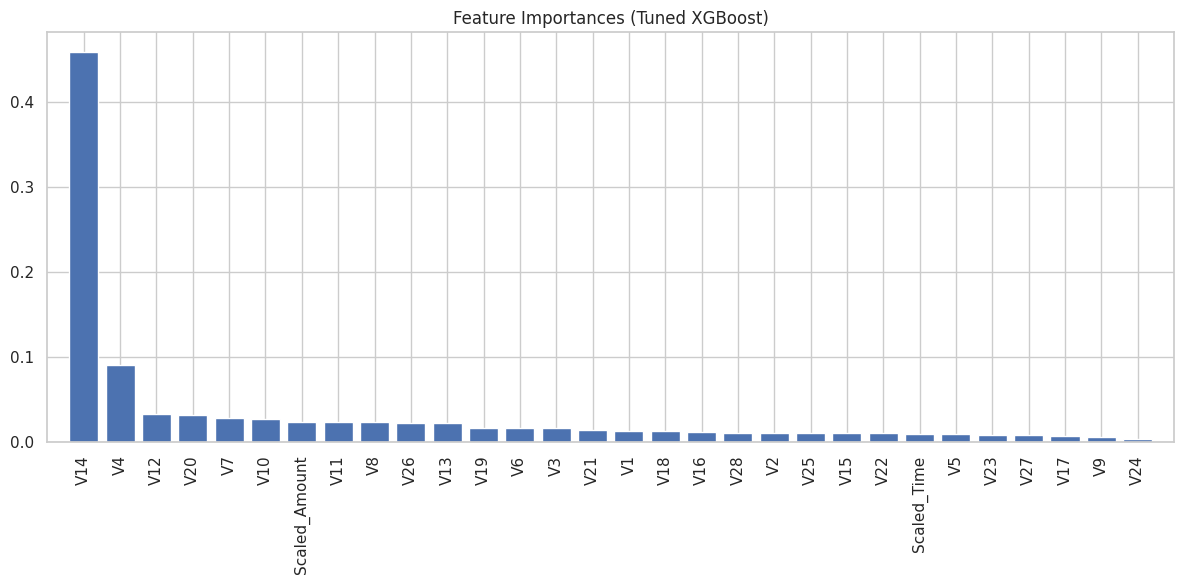

In [ ]:
# --- FEATURE IMPORTANCES ---
print("\n--- FEATURE IMPORTANCES (BEST XGBOOST MODEL) ---")
importances = best_xgb.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Tuned XGBoost)")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()

-----------------------
# Model Simplification (Top 5 vs Top 10 Features)
In real-world scenarios, knowing the most important features (like `V14` and `V4`) allows us to:
1. **Simplify Models:** Smaller models have faster inference times in production, which is crucial for real-time credit card processing.
2. **Create Fallback Rules:** Engineers can hard-code simple `IF` statements (e.g., "If V14 < threshold, flag immediately") to pre-filter obvious fraud and save compute resources.
3. **Business Intelligence:** If these features weren't PCA-anonymized, we could translate them directly into actionable business insights (ex, "Transactions over $500 far from home are highly risky").

XGBoost model using only the Top 5 and Top 10 features to see how much predictive power we retain compared to using all 30 features:

In [ ]:
# Get the names of the top 5 and top 10 features
top_5_features = X_train.columns[indices[:5]]
top_10_features = X_train.columns[indices[:10]]

print(f"Top 5 Features: {list(top_5_features)}")
print(f"Top 10 Features: {list(top_10_features)}")

# Create simplified datasets
X_train_top5 = X_train[top_5_features]
X_test_top5 = X_test[top_5_features]

X_train_top10 = X_train[top_10_features]
X_test_top10 = X_test[top_10_features]

Top 5 Features: ['V14', 'V4', 'V12', 'V20', 'V7']
Top 10 Features: ['V14', 'V4', 'V12', 'V20', 'V7', 'V10', 'Scaled_Amount', 'V11', 'V8', 'V26']


--- XGBOOST (TOP 5 FEATURES) ---


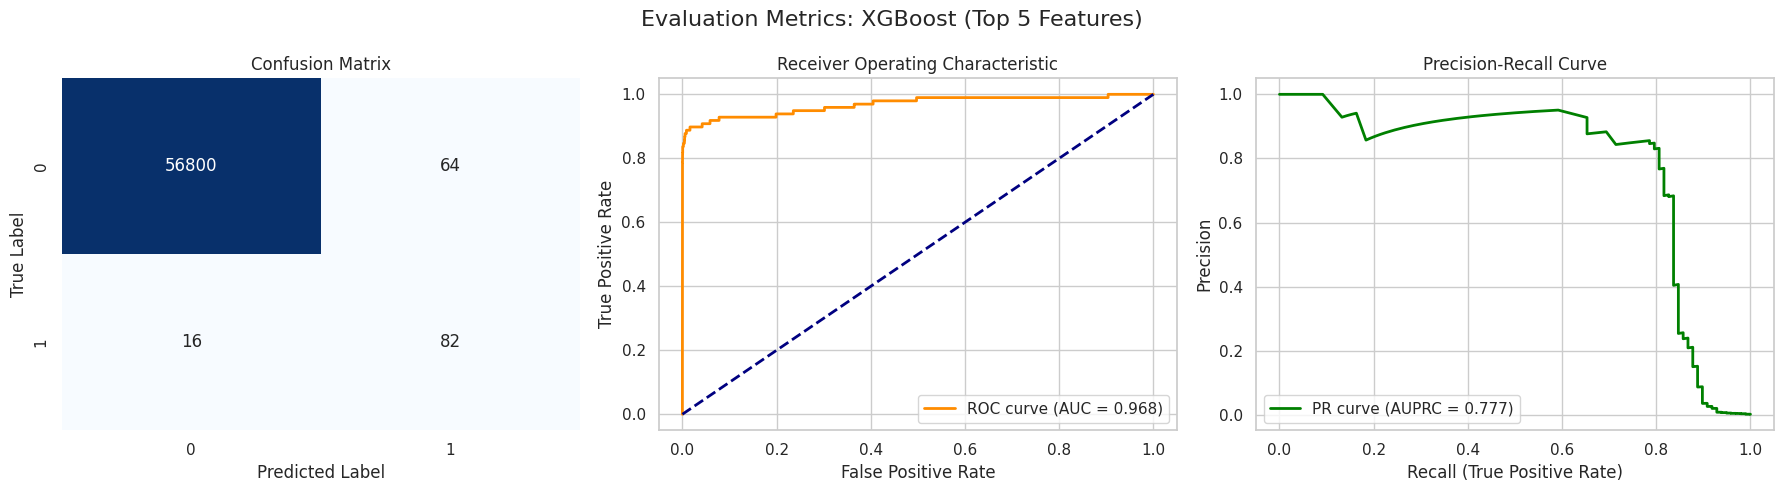

Classification Report for XGBoost (Top 5 Features):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.56      0.84      0.67        98

    accuracy                           1.00     56962
   macro avg       0.78      0.92      0.84     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
# Results: 84% Recall, 56% Precision
# Maintains high recall, but precision drops significantly compared to the full model.
print("--- XGBOOST (TOP 5 FEATURES) ---")
# Reuse the best hyperparameters we found earlier
xgb_top5 = XGBClassifier(**best_xgb.get_params())
xgb_top5.fit(X_train_top5, y_train)

evaluate_model(xgb_top5, X_test_top5, y_test, "XGBoost (Top 5 Features)")

--- XGBOOST (TOP 10 FEATURES) ---


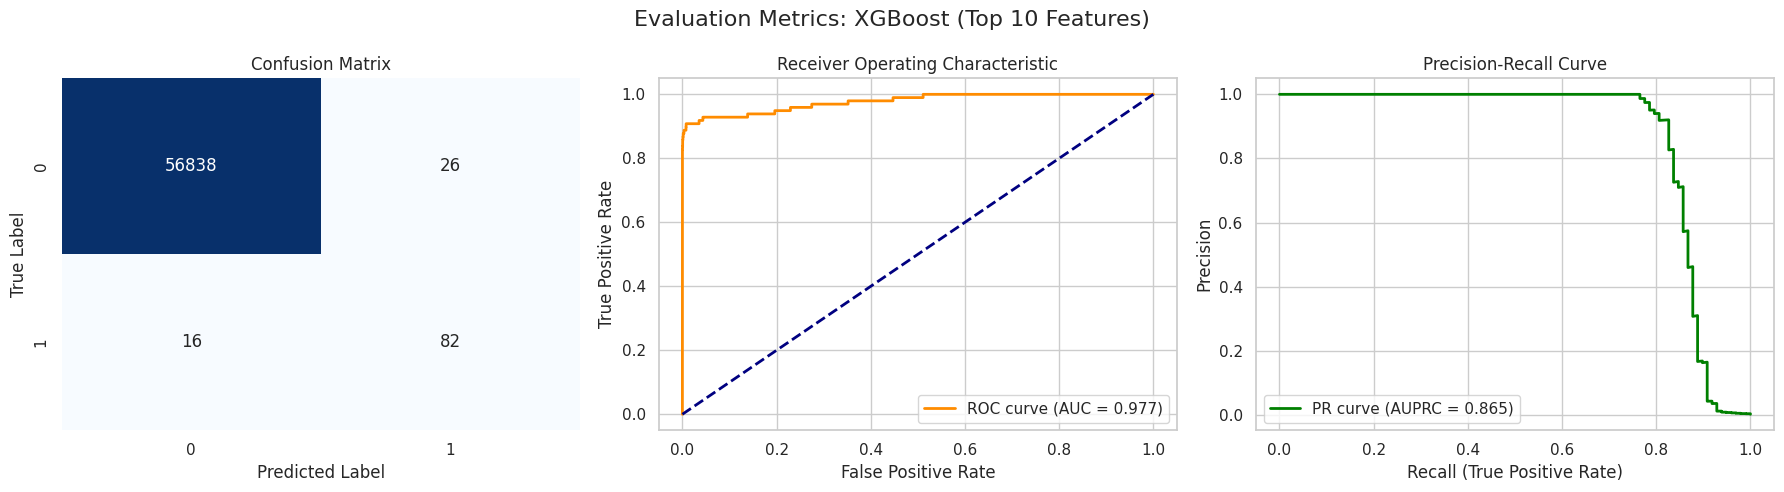

Classification Report for XGBoost (Top 10 Features):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.76      0.84      0.80        98

    accuracy                           1.00     56962
   macro avg       0.88      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
# Results: 84% Recall, 76% Precision
# Much better precision than the Top 5 model, while retaining the same recall. A great balance for a simplified model.
print("--- XGBOOST (TOP 10 FEATURES) ---")
xgb_top10 = XGBClassifier(**best_xgb.get_params())
xgb_top10.fit(X_train_top10, y_train)

evaluate_model(xgb_top10, X_test_top10, y_test, "XGBoost (Top 10 Features)")

-------------------
# Conclusion

Initial baselines showed a Random Forest model using SMOTE-augmented data performing quite well, with 82% recall. However, this model produced ~1,500 false positives. If this was a production model for a credit union, our call center would be slammed trying to reactivate peoples' cards after they were falsely flagged for fraud.

XGBoost is our highest-performing model with 86% recall and 0.879 AUPRC, along with negligible false positives. The only preprocessing we did to the dataset was to scale the `Time` and `Amount` features. Since XGBoost natively handles imbalanced datasets like ours, we used the original data without synthetic SMOTE data or Random Undersampling reduction.

To optimize XGBoost, we used class weighting (overemphasizing the minority `Fraud` class), hyperparameter tuning and threshold tuning.

We also attempted a lighter-weight model using the top 10 and top 5 most important features. The model using the top 10 performed only slightly worse than the full model with 30 features. The top 5 model started showing a greater amount of false positives, but still predicted fraud at a better rate than our baseline models.